# 04 Ablation 2: Encoding Strategy

**Research question**: 
~~Does Target Encoding outperform Label Encoding for categorical features in this multiclass intrusion detection task?~~

Does Frequency Encoding outperform Ordinal Encoding for nominal categorical features in this multiclass intrusion detection task, when the best class imbalance strategy from Ablation 1 is fixed?

**Design**:
- Model: Random Forest (fixed)
- ~~Class imbalance strategy: best result from Ablation 1 (fixed = SMOTE)~~
- Class imbalance strategy: best result from Ablation 1, loaded from `data/outputs/ablation1_best_config.json`
- Variable: encoding strategy
- Train/test split: loaded from baseline processed files

**Strategies compared**:
1. ~~Label Encoding (baseline)~~
1. Ordinal Encoding
2. ~~Target Encoding~~
2. Frequency Encoding

**Primary metric**: Per-class Recall  
**Secondary metrics**: Macro F1, attack predicted as Normal

> **Updated note on Ablation 1 dependency**:
> Notebook 04 should be run after Notebook 03.
> Notebook 04 reads the best class imbalance strategy from:
>
> `data/outputs/ablation1_best_config.json`
>
> If the file does not exist, the notebook uses `Capped_SMOTENC_50000` as the default fallback.

> **Updated note on encoding**:
> - Ordinal Encoding converts nominal categories such as `proto`, `state`, and `service` into integer-like encoded values.
> - Frequency Encoding replaces each category with its frequency in the training set.
> - Frequency Encoding does not use the target label, so it avoids the target leakage risk of naive Target Encoding.
> - Numeric-like columns such as `sport`, `dsport`, and `ct_ftp_cmd` are cleaned using training-set mean imputation before encoding comparison.

> **Reason for replacing Target Encoding**:
> ~~Target Encoding was originally planned because protocol/service/state may be related to attack type.~~
>
> The current Target Encoding implementation was removed from the main ablation because multiclass labels would need to be converted into arbitrary numbers. This can make the encoded values methodologically weak because attack classes are nominal, not ordinal.

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

import json
from pathlib import Path

from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score

from imblearn.over_sampling import RandomOverSampler, SMOTE, SMOTENC
from imblearn.under_sampling import RandomUnderSampler

PROJECT_ROOT = Path('..')
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
OUTPUT_DIR = PROJECT_ROOT / 'data' / 'outputs'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42

best_config_path = OUTPUT_DIR / 'ablation1_best_config.json'

if best_config_path.exists():
    with open(best_config_path, 'r') as f:
        best_config = json.load(f)
    BEST_IMBALANCE_STRATEGY = best_config['best_strategy']
    OVERSAMPLE_CAP_VALUE = int(best_config.get('oversample_cap_value', 50_000))
else:
    BEST_IMBALANCE_STRATEGY = 'Capped_SMOTENC_50k'
    OVERSAMPLE_CAP_VALUE = 50_000

print('Best imbalance strategy:', BEST_IMBALANCE_STRATEGY)
print('Oversample cap value:', OVERSAMPLE_CAP_VALUE)

Best imbalance strategy: Capped_SMOTENC_50k
Oversample cap value: 50000


In [2]:
X_train = pd.read_csv(PROCESSED_DIR / 'X_train_baseline.csv')
X_test  = pd.read_csv(PROCESSED_DIR / 'X_test_baseline.csv')
y_train = pd.read_csv(PROCESSED_DIR / 'y_train_baseline.csv').squeeze()
y_test  = pd.read_csv(PROCESSED_DIR / 'y_test_baseline.csv').squeeze()

print('Loaded baseline data')
print('X_train:', X_train.shape)
print('X_test:', X_test.shape)

Loaded baseline data
X_train: (2032037, 43)
X_test: (508010, 43)


In [3]:
NOMINAL_CATEGORICAL_COLS = ['proto', 'state', 'service']
NUMERIC_LIKE_COLS = ['sport', 'dsport', 'ct_ftp_cmd']


def clean_numeric_like_columns(X_train, X_test, numeric_like_cols):
    X_train = X_train.copy()
    X_test = X_test.copy()

    for col in numeric_like_cols:
        if col not in X_train.columns:
            continue

        X_train[col] = pd.to_numeric(X_train[col], errors='coerce')
        X_test[col] = pd.to_numeric(X_test[col], errors='coerce')

        fill_value = X_train[col].mean()
        if pd.isna(fill_value):
            fill_value = 0

        X_train[col] = X_train[col].fillna(fill_value).astype(np.float32)
        X_test[col] = X_test[col].fillna(fill_value).astype(np.float32)

    return X_train, X_test


def prepare_ordinal_features(X_train, X_test, categorical_cols, numeric_like_cols):
    X_train_enc, X_test_enc = clean_numeric_like_columns(
        X_train,
        X_test,
        numeric_like_cols
    )

    categorical_cols = [c for c in categorical_cols if c in X_train_enc.columns]

    encoder = OrdinalEncoder(
        handle_unknown='use_encoded_value',
        unknown_value=-1,
        dtype=np.float32
    )

    X_train_enc[categorical_cols] = encoder.fit_transform(
        X_train_enc[categorical_cols].astype(str)
    )
    X_test_enc[categorical_cols] = encoder.transform(
        X_test_enc[categorical_cols].astype(str)
    )

    categorical_indices = [
        X_train_enc.columns.get_loc(c)
        for c in categorical_cols
    ]

    return X_train_enc, X_test_enc, categorical_indices, encoder


def prepare_frequency_features(X_train, X_test, categorical_cols, numeric_like_cols):
    X_train_enc, X_test_enc = clean_numeric_like_columns(
        X_train,
        X_test,
        numeric_like_cols
    )

    categorical_cols = [c for c in categorical_cols if c in X_train_enc.columns]

    for col in categorical_cols:
        freq_map = X_train_enc[col].astype(str).value_counts(normalize=True)

        X_train_enc[col] = (
            X_train_enc[col]
            .astype(str)
            .map(freq_map)
            .fillna(0)
            .astype(np.float32)
        )
        X_test_enc[col] = (
            X_test_enc[col]
            .astype(str)
            .map(freq_map)
            .fillna(0)
            .astype(np.float32)
        )

    return X_train_enc, X_test_enc


def make_oversample_strategy(y, cap=50_000):
    counts = y.value_counts()
    majority_class = counts.idxmax()
    second_largest = int(counts.sort_values(ascending=False).iloc[1])
    target = min(second_largest, cap)

    strategy = {
        cls: target
        for cls, cnt in counts.items()
        if cls != majority_class and cnt < target
    }

    return strategy, target, majority_class, second_largest


def apply_imbalance_strategy(X, y, strategy, categorical_indices=None):
    cnts = y.value_counts()
    oversample_strategy, oversample_target, majority_class, second_largest = make_oversample_strategy(
        y,
        cap=OVERSAMPLE_CAP_VALUE
    )

    if strategy == 'None':
        return X, y

    if strategy == 'class_weight':
        return X, y

    if strategy == 'RandomOverSampling':
        sampler = RandomOverSampler(
            sampling_strategy=oversample_strategy,
            random_state=RANDOM_STATE
        )
        return sampler.fit_resample(X, y)

    if strategy == 'RandomUnderSampling':
        rus_strategy = {
            cls: (second_largest if cls == majority_class else int(cnt))
            for cls, cnt in cnts.items()
        }
        sampler = RandomUnderSampler(
            sampling_strategy=rus_strategy,
            random_state=RANDOM_STATE
        )
        return sampler.fit_resample(X, y)

    if strategy.startswith('Capped_SMOTENC') or strategy == 'SMOTE':
        min_count = cnts.min()
        k_neighbors = min(5, int(min_count) - 1)

        if k_neighbors < 1:
            print('Skipping synthetic oversampling because at least one class has fewer than 2 samples.')
            return X, y

        if categorical_indices is not None and len(categorical_indices) > 0:
            sampler = SMOTENC(
                categorical_features=categorical_indices,
                sampling_strategy=oversample_strategy,
                random_state=RANDOM_STATE,
                k_neighbors=k_neighbors
            )
        else:
            sampler = SMOTE(
                sampling_strategy=oversample_strategy,
                random_state=RANDOM_STATE,
                k_neighbors=k_neighbors
            )

        return sampler.fit_resample(X, y)

    raise ValueError(f'Unknown strategy: {strategy}')


def run_rf_experiment(X_tr, y_tr, X_te, y_te, encoding_name, class_weight=None):
    clf = RandomForestClassifier(
        n_estimators=100,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        class_weight=class_weight
    )

    clf.fit(X_tr, y_tr)
    y_pred = clf.predict(X_te)

    report = classification_report(y_te, y_pred, output_dict=True, zero_division=0)
    macro_f1 = f1_score(y_te, y_pred, average='macro', zero_division=0)

    classes = sorted(y_te.unique())
    cm = confusion_matrix(y_te, y_pred, labels=classes)
    normal_idx = classes.index('Normal')
    attack_indices = [i for i, c in enumerate(classes) if c != 'Normal']
    attack_to_normal = int(cm[attack_indices, normal_idx].sum())

    print(f'\n=== {encoding_name} ===')
    print(classification_report(y_te, y_pred, zero_division=0))
    print(f'Attack predicted as Normal: {attack_to_normal:,}')

    return report, macro_f1, attack_to_normal, clf


class_weight_param = 'balanced' if BEST_IMBALANCE_STRATEGY == 'class_weight' else None

In [4]:
# --- Ordinal Encoding ---
X_train_ord, X_test_ord, categorical_indices, ordinal_encoder = prepare_ordinal_features(
    X_train,
    X_test,
    NOMINAL_CATEGORICAL_COLS,
    NUMERIC_LIKE_COLS
)

X_tr_ord, y_tr_ord = apply_imbalance_strategy(
    X_train_ord,
    y_train,
    BEST_IMBALANCE_STRATEGY,
    categorical_indices=categorical_indices
)

print(f'Ordinal Encoding after {BEST_IMBALANCE_STRATEGY}: {X_train_ord.shape[0]:,} -> {X_tr_ord.shape[0]:,} samples')

report_ord, macro_f1_ord, attack_to_normal_ord, clf_ord = run_rf_experiment(
    X_tr_ord,
    y_tr_ord,
    X_test_ord,
    y_test,
    encoding_name='Ordinal Encoding',
    class_weight=class_weight_param
)

Ordinal Encoding after Capped_SMOTENC_50k: 2,032,037 -> 2,347,396 samples

=== Ordinal Encoding ===
                precision    recall  f1-score   support

      Analysis       0.09      0.20      0.13       535
      Backdoor       0.05      0.11      0.07       466
           DoS       0.34      0.53      0.42      3271
      Exploits       0.78      0.61      0.69      8905
       Fuzzers       0.67      0.67      0.67      4849
       Generic       1.00      0.99      0.99     43096
        Normal       1.00      1.00      1.00    443753
Reconnaissance       0.91      0.77      0.83      2798
     Shellcode       0.75      0.97      0.85       302
         Worms       0.36      0.57      0.44        35

      accuracy                           0.98    508010
     macro avg       0.59      0.64      0.61    508010
  weighted avg       0.98      0.98      0.98    508010

Attack predicted as Normal: 1,201


=== Label Encoding ===


                precision    recall  f1-score   support

      Analysis       0.09      0.17      0.12       535
      Backdoor       0.05      0.11      0.07       466
           DoS       0.34      0.53      0.41      3271
      Exploits       0.78      0.62      0.69      8905
       Fuzzers       0.67      0.66      0.67      4849
       Generic       1.00      0.99      0.99     43096
        Normal       1.00      1.00      1.00    443753
Reconnaissance       0.89      0.78      0.83      2798
     Shellcode       0.59      0.92      0.72       302
         Worms       0.44      0.60      0.51        35

      accuracy                           0.98    508010
     macro avg       0.58      0.64      0.60    508010
  weighted avg       0.98      0.98      0.98    508010



In [5]:
# --- Frequency Encoding ---
X_train_freq, X_test_freq = prepare_frequency_features(
    X_train,
    X_test,
    NOMINAL_CATEGORICAL_COLS,
    NUMERIC_LIKE_COLS
)

X_tr_freq, y_tr_freq = apply_imbalance_strategy(
    X_train_freq,
    y_train,
    BEST_IMBALANCE_STRATEGY,
    categorical_indices=None
)

print(f'Frequency Encoding after {BEST_IMBALANCE_STRATEGY}: {X_train_freq.shape[0]:,} -> {X_tr_freq.shape[0]:,} samples')

report_freq, macro_f1_freq, attack_to_normal_freq, clf_freq = run_rf_experiment(
    X_tr_freq,
    y_tr_freq,
    X_test_freq,
    y_test,
    encoding_name='Frequency Encoding',
    class_weight=class_weight_param
)

Frequency Encoding after Capped_SMOTENC_50k: 2,032,037 -> 2,347,396 samples

=== Frequency Encoding ===
                precision    recall  f1-score   support

      Analysis       0.10      0.18      0.13       535
      Backdoor       0.05      0.10      0.06       466
           DoS       0.34      0.45      0.38      3271
      Exploits       0.74      0.66      0.70      8905
       Fuzzers       0.68      0.67      0.67      4849
       Generic       1.00      0.99      0.99     43096
        Normal       1.00      1.00      1.00    443753
Reconnaissance       0.90      0.78      0.84      2798
     Shellcode       0.75      0.96      0.84       302
         Worms       0.39      0.60      0.47        35

      accuracy                           0.98    508010
     macro avg       0.59      0.64      0.61    508010
  weighted avg       0.98      0.98      0.98    508010

Attack predicted as Normal: 1,208


=== Target Encoding ===


                precision    recall  f1-score   support

      Analysis       0.10      0.17      0.12       535
      Backdoor       0.05      0.09      0.06       466
           DoS       0.33      0.37      0.35      3271
      Exploits       0.71      0.66      0.68      8905
       Fuzzers       0.63      0.54      0.58      4849
       Generic       0.99      0.99      0.99     43096
        Normal       1.00      1.00      1.00    443753
Reconnaissance       0.85      0.78      0.81      2798
     Shellcode       0.74      0.98      0.84       302
         Worms       0.15      0.51      0.24        35

      accuracy                           0.98    508010
     macro avg       0.55      0.61      0.57    508010
  weighted avg       0.98      0.98      0.98    508010



In [6]:
classes = sorted(y_test.unique())

encoding_results = {
    'Ordinal Encoding': {
        'report': report_ord,
        'macro_f1': macro_f1_ord,
        'attack_to_normal': attack_to_normal_ord
    },
    'Frequency Encoding': {
        'report': report_freq,
        'macro_f1': macro_f1_freq,
        'attack_to_normal': attack_to_normal_freq
    }
}

rows = []
for cls in classes:
    row = {'class': cls}
    for enc_name, result in encoding_results.items():
        row[enc_name] = round(result['report'].get(cls, {}).get('recall', 0.0), 4)
    rows.append(row)

macro_row = {'class': 'Macro F1'}
for enc_name, result in encoding_results.items():
    macro_row[enc_name] = round(result['macro_f1'], 4)
rows.append(macro_row)

fn_row = {'class': 'Attack predicted as Normal'}
for enc_name, result in encoding_results.items():
    fn_row[enc_name] = result['attack_to_normal']
rows.append(fn_row)

summary_df = pd.DataFrame(rows).set_index('class')

print(f'\nEncoding comparison (imbalance strategy fixed: {BEST_IMBALANCE_STRATEGY})')
print(summary_df.to_string())

summary_df.to_csv(OUTPUT_DIR / 'ablation2_encoding_results.csv')
print('\nSaved to data/outputs/ablation2_encoding_results.csv')


Encoding comparison (imbalance strategy fixed: Capped_SMOTENC_50k)
                            Ordinal Encoding  Frequency Encoding
class                                                           
Analysis                              0.1981              0.1794
Backdoor                              0.1137              0.0987
DoS                                   0.5347              0.4451
Exploits                              0.6116              0.6608
Fuzzers                               0.6674              0.6657
Generic                               0.9866              0.9870
Normal                                0.9968              0.9967
Reconnaissance                        0.7741              0.7841
Shellcode                             0.9669              0.9570
Worms                                 0.5714              0.6000
Macro F1                              0.6079              0.6085
Attack predicted as Normal         1201.0000           1208.0000

Saved to data/outputs

                Label Encoding  Target Encoding
class                                          
Analysis                0.1720           0.1701
Backdoor                0.1052           0.0858
DoS                     0.5307           0.3669
Exploits                0.6179           0.6597
Fuzzers                 0.6579           0.5403
Generic                 0.9866           0.9869
Normal                  0.9967           0.9968
Reconnaissance          0.7781           0.7784
Shellcode               0.9238           0.9834
Worms                   0.6000           0.5143
Macro F1                0.5999           0.5676

Saved to data/outputs/ablation2_encoding_results.csv


In [7]:
attack_classes = [c for c in classes if c != 'Normal']

avg_attack_recall = {}
for enc_name, result in encoding_results.items():
    avg_attack_recall[enc_name] = np.mean([
        result['report'].get(c, {}).get('recall', 0.0)
        for c in attack_classes
    ])

best_encoding = max(avg_attack_recall, key=avg_attack_recall.get)

for enc_name, value in sorted(avg_attack_recall.items(), key=lambda x: -x[1]):
    marker = ' <-- BEST' if enc_name == best_encoding else ''
    print(f'{enc_name} avg attack Recall: {value:.4f}{marker}')

print(f'\nBest encoding: {best_encoding}')
print('This encoding strategy will be passed to Stream A and Stream B.')

best_encoding_config = {
    'best_encoding': best_encoding,
    'imbalance_strategy': BEST_IMBALANCE_STRATEGY,
    'selection_metric': 'average_attack_recall',
    'average_attack_recall': float(avg_attack_recall[best_encoding]),
    'macro_f1': float(encoding_results[best_encoding]['macro_f1']),
    'attack_to_normal': int(encoding_results[best_encoding]['attack_to_normal'])
}

with open(OUTPUT_DIR / 'ablation2_best_config.json', 'w') as f:
    json.dump(best_encoding_config, f, indent=2)

print('\nSaved best Ablation 2 config to data/outputs/ablation2_best_config.json')
print(best_encoding_config)

Ordinal Encoding avg attack Recall: 0.6027 <-- BEST
Frequency Encoding avg attack Recall: 0.5975

Best encoding: Ordinal Encoding
This encoding strategy will be passed to Stream A and Stream B.

Saved best Ablation 2 config to data/outputs/ablation2_best_config.json
{'best_encoding': 'Ordinal Encoding', 'imbalance_strategy': 'Capped_SMOTENC_50k', 'selection_metric': 'average_attack_recall', 'average_attack_recall': 0.6027262104956314, 'macro_f1': 0.6078794058108312, 'attack_to_normal': 1201}


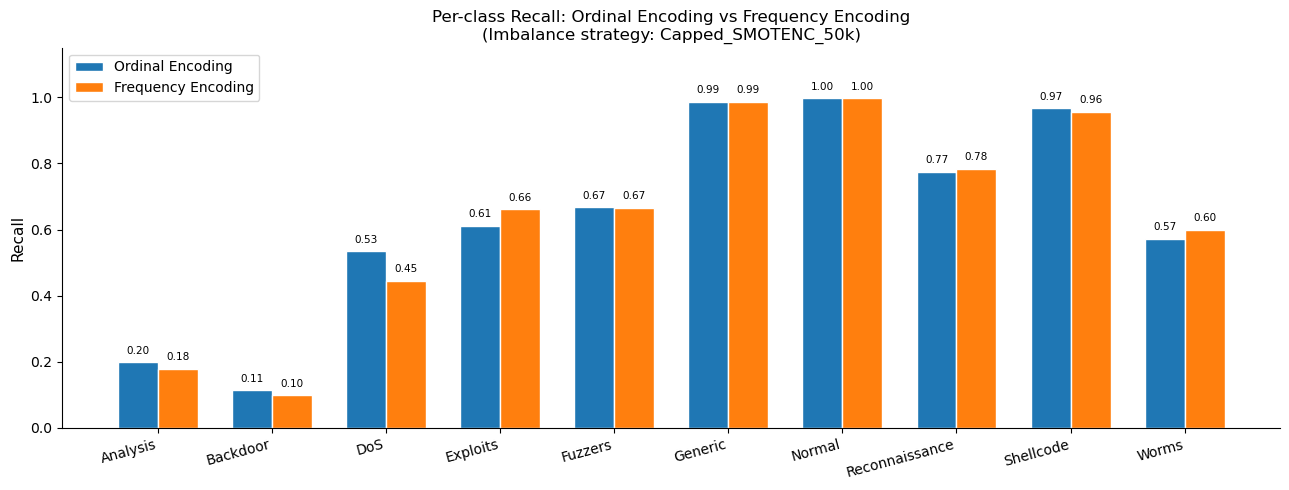

Saved: reports/ablation2_encoding_recall.png


In [8]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'

FIGURE_DIR = PROJECT_ROOT / 'reports'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

classes_plot = sorted(y_test.unique())
x = np.arange(len(classes_plot))
width = 0.35

ord_recalls = [report_ord.get(c, {}).get('recall', 0.0) for c in classes_plot]
freq_recalls = [report_freq.get(c, {}).get('recall', 0.0) for c in classes_plot]

fig, ax = plt.subplots(figsize=(13, 5))
bars1 = ax.bar(x - width/2, ord_recalls, width, label='Ordinal Encoding', edgecolor='white')
bars2 = ax.bar(x + width/2, freq_recalls, width, label='Frequency Encoding', edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(classes_plot, fontsize=10, rotation=15, ha='right')
ax.set_ylabel('Recall', fontsize=11)
ax.set_ylim(0, 1.15)
ax.set_title(
    f'Per-class Recall: Ordinal Encoding vs Frequency Encoding\n'
    f'(Imbalance strategy: {BEST_IMBALANCE_STRATEGY})',
    fontsize=12
)
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

for bar in bars1:
    h = bar.get_height()
    if h > 0.02:
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.02, f'{h:.2f}',
                ha='center', va='bottom', fontsize=7.5)

for bar in bars2:
    h = bar.get_height()
    if h > 0.02:
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.02, f'{h:.2f}',
                ha='center', va='bottom', fontsize=7.5)

plt.tight_layout()
plt.savefig(FIGURE_DIR / 'ablation2_encoding_recall.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved: reports/ablation2_encoding_recall.png')

## Ablation 2 Conclusion

Record the best encoding strategy here after running.

The best encoding strategy is selected using average attack-class Recall, excluding the Normal class.

The selected encoding strategy is saved automatically to:

- `data/outputs/ablation2_best_config.json`

**Fixed pipeline for downstream notebooks:**
- Class imbalance strategy: loaded from Ablation 1 best config
- Encoding strategy: `[Ablation 2 best encoding]`

~~Class imbalance strategy: SMOTE (Ablation 1 best)~~  
Class imbalance strategy: `[Ablation 1 best strategy from ablation1_best_config.json]`

~~Encoding strategy: Label Encoding or Target Encoding~~  
Encoding strategy: `Ordinal Encoding` or `Frequency Encoding`

Pass these two decisions to:
- Notebook 05, 06 (Stream A — 서하)
- Notebook 07 (Stream B — 준원)

Figure saved to `reports/`:
- `ablation2_encoding_recall.png` — PPT 삽입용